# Análisis de sesión de elicitación — AURA/IRIS (I2)

Cruza el CSV de **elicitación de clips** (ground truth real: qué emoción se indujo y qué reportó la persona) con el CSV de **sesión** del detector (predicciones frame a frame de los 3-4 motores) para calcular accuracy, recall y matrices de confusión reales — no aproximadas con selfies.

**Cómo usar esta notebook:**
1. Pon los CSVs de elicitación y de sesión en `notebooks/data/` (o ajusta las rutas en la celda de configuración).
2. Si quieres comparar dos sesiones (ej. histéresis vieja 0.70/600ms vs. nueva 0.45/300ms), agrega ambas al diccionario `SESIONES` — cada una con su propio CSV de elicitación si usaste protocolos distintos, o el mismo si repetiste igual.
3. Corre todas las celdas en orden.

**Motores comparados** (se auto-detectan según qué columnas tenga el CSV — sesiones viejas sin `faceapi_*`/`mlp_raw_*` simplemente se saltan esos motores sin error):
- `activo` — lo que el panel le muestra a la gente (columnas `neutral,happy,sad,...`), sea cual sea el motor seleccionado en `classifierSel` durante la grabación.
- `faceapi` — faceExpressionNet crudo (columnas `faceapi_*`).
- `fusion` — emotion-fusion.js (columnas `fusion_*`).
- `mlp_activo` — modelo propio con parche de "sad" + suavizado EMA/histéresis (columnas `mlp_*`).
- `mlp_crudo` — modelo propio sin parche ni suavizado (columnas `mlp_raw_*`), solo en sesiones grabadas después del 21 jul 2026.


In [1]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 1. Configuración

Edita estas rutas y nombres antes de correr el resto.

In [ ]:
# Diccionario de sesiones a analizar (puedes poner 1 o varias para comparar).
# Cada sesión necesita su propio CSV de sesión; el CSV de elicitación puede
# compartirse entre sesiones si repetiste el mismo protocolo.
SESIONES = {
    "histeresis_0.45_300ms": {
        "sesion_csv": "data/sesion_2026-07-21-19-15-35.csv",
        "elicitacion_csv": "data/elicitacion_clips_2026-07-21T19-05-57-936Z.csv",
    },
}

# Mapeo etiqueta reportada en el protocolo de elicitación -> clase del modelo (7 clases).
# Ajusta si usas categorías/clips distintos. "Neutral" se incluye porque en la
# sesión del 21 jul (19:05) el clip de miedo se auto-reportó como "Neutral"
# (ya_visto=Si, clip repetido con menor impacto emocional) — sin este mapeo esas
# ventanas se hubieran descartado del análisis en vez de contarse como neutral real.
MAPEO_EMOCION_REPORTADA = {
    "Alegría": "happy",
    "Miedo": "fearful",
    "Asco": "disgusted",
    "Ira": "angry",
    "Tristeza": "sad",
    "Neutral": "neutral",
    # "Sorpresa": "surprised",  # agrega si tu protocolo incluye un clip de sorpresa
}

CLASSES = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

## 2. Funciones de carga

No deberías necesitar tocar esta sección.

In [6]:
def cargar_sesion(path):
    '''Parsea el CSV de sesión (formato de dos secciones separadas por
    '### SECCION: ...'). Devuelve el DataFrame de la sección 'emociones' con
    columna 'ts' ya parseada a datetime.'''
    with open(path, encoding="utf-8-sig") as f:
        lines = f.readlines()
    sec1_start = next(i for i, l in enumerate(lines) if "SECCION: emociones" in l) + 1
    sec2_idx = next((i for i, l in enumerate(lines) if "SECCION: momentos_clave" in l), len(lines))
    emo_lines = [l for l in lines[sec1_start:sec2_idx] if l.strip()]
    sess = pd.read_csv(StringIO("".join(emo_lines)))
    sess["ts"] = pd.to_datetime(sess["timestamp_iso"])
    return sess


def cargar_elicitacion(path, mapeo=MAPEO_EMOCION_REPORTADA):
    '''Parsea el CSV de elicitación y agrega columna 'gt' (ground truth,
    ya mapeada a una de las 7 clases del modelo) e 'inicio'/'fin' en datetime.
    Las filas de categoría 'fijacion' se tratan como ground truth 'neutral'.'''
    elic = pd.read_csv(path)
    elic["inicio"] = pd.to_datetime(elic["timestamp_inicio_iso"])
    elic["fin"] = pd.to_datetime(elic["timestamp_fin_iso"])

    def label_for(row):
        if row["categoria"] == "fijacion":
            return "neutral"
        return mapeo.get(row["emocion_reportada"], None)

    elic["gt"] = elic.apply(label_for, axis=1)
    return elic


def cruzar_por_tiempo(sess, elic):
    '''Asigna a cada frame de sesión el ground truth de la ventana de
    elicitación en la que cae (o None si no cae en ninguna — frames entre
    ventanas se descartan del análisis, es esperado).'''
    def find_gt(ts):
        m = elic[(elic["inicio"] <= ts) & (ts <= elic["fin"])]
        if len(m) == 0:
            return None, None
        r = m.iloc[0]
        return r["gt"], r["paso"]

    gts, pasos = zip(*sess["ts"].map(find_gt))
    sess = sess.copy()
    sess["gt"] = gts
    sess["paso"] = pasos
    return sess.dropna(subset=["gt"])


def motores_disponibles(df):
    '''Detecta qué motores tiene esta sesión según las columnas presentes.
    Devuelve dict {nombre_motor: prefijo_de_columna}.'''
    motores = {"activo": ""}  # siempre presente: neutral,happy,sad,...
    if "faceapi_neutral" in df.columns:
        motores["faceapi"] = "faceapi_"
    if "fusion_neutral" in df.columns:
        motores["fusion"] = "fusion_"
    if "mlp_neutral" in df.columns:
        motores["mlp_activo"] = "mlp_"
    if "mlp_raw_neutral" in df.columns:
        motores["mlp_crudo"] = "mlp_raw_"
    return motores


def dominante(row, prefix):
    vals = {c: row.get(f"{prefix}{c}", np.nan) for c in CLASSES}
    vals = {k: v for k, v in vals.items() if pd.notna(v)}
    if not vals:
        return None
    return max(vals, key=vals.get)


## 3. Cargar, cruzar y calcular predicciones por motor

In [7]:
resultados = {}  # nombre_sesion -> DataFrame etiquetado con predicciones por motor

for nombre_sesion, paths in SESIONES.items():
    sess = cargar_sesion(paths["sesion_csv"])
    elic = cargar_elicitacion(paths["elicitacion_csv"])
    labeled = cruzar_por_tiempo(sess, elic)

    motores = motores_disponibles(labeled)
    print(f"=== {nombre_sesion} ===")
    print(f"  Frames totales: {len(sess)} | Frames con ground truth: {len(labeled)}")
    print(f"  Motores detectados: {list(motores.keys())}")
    print(f"  Distribución de ground truth:\n{labeled['gt'].value_counts().to_string()}")
    print()

    for motor, prefix in motores.items():
        labeled[f"pred_{motor}"] = labeled.apply(lambda r: dominante(r, prefix), axis=1)

    resultados[nombre_sesion] = labeled


FileNotFoundError: [Errno 2] No such file or directory: 'data/elicitacion_clips_2026-07-21T18-05-58-264Z_1_.csv'

## 4. Accuracy global y recall por clase, por motor

In [5]:
def resumen_motor(labeled, motor):
    col = f"pred_{motor}"
    acc = (labeled[col] == labeled["gt"]).mean()
    filas = []
    for c in sorted(labeled["gt"].dropna().unique()):
        sub = labeled[labeled["gt"] == c]
        recall = (sub[col] == c).mean()
        filas.append({"clase": c, "n": len(sub), "recall": recall})
    return acc, pd.DataFrame(filas)


for nombre_sesion, labeled in resultados.items():
    motores = [c.replace("pred_", "") for c in labeled.columns if c.startswith("pred_")]
    print(f"\n########## {nombre_sesion} ##########")
    for motor in motores:
        acc, df_recall = resumen_motor(labeled, motor)
        print(f"\n--- {motor} --- accuracy global = {acc:.3f} (n={len(labeled)})")
        print(df_recall.to_string(index=False))



########## histeresis_0.70_600ms ##########

--- activo --- accuracy global = 0.125 (n=248)
    clase   n   recall
disgusted  69 0.028986
    happy 160 0.062500
  neutral  19 1.000000

--- faceapi --- accuracy global = 0.117 (n=248)
    clase   n   recall
disgusted  69 0.014493
    happy 160 0.056250
  neutral  19 1.000000

--- fusion --- accuracy global = 0.097 (n=248)
    clase   n  recall
disgusted  69 0.00000
    happy 160 0.03125
  neutral  19 1.00000

--- mlp_activo --- accuracy global = 0.121 (n=248)
    clase   n   recall
disgusted  69 0.028986
    happy 160 0.056250
  neutral  19 1.000000

--- mlp_crudo --- accuracy global = 0.044 (n=248)
    clase   n   recall
disgusted  69 0.028986
    happy 160 0.031250
  neutral  19 0.210526


## 5. Matriz de confusión (por sesión y motor)

Cambia `SESION_A_GRAFICAR` y `MOTOR_A_GRAFICAR` para ver otras combinaciones.

pred_activo,angry,disgusted,happy,neutral
gt,,,,
disgusted,0,2,0,67
happy,2,3,10,145
neutral,0,0,0,19


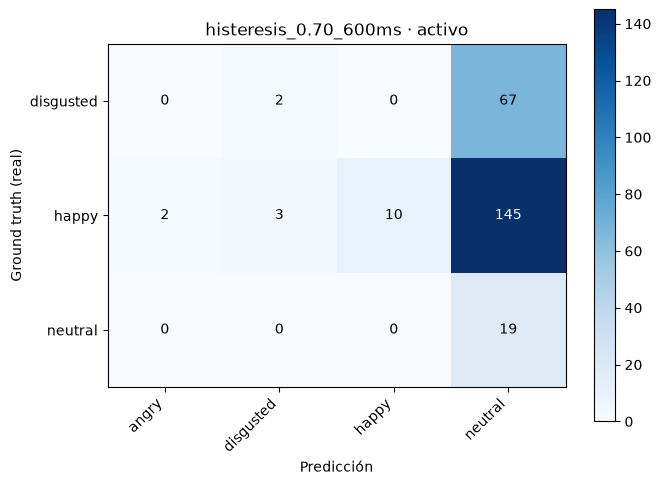

In [6]:
SESION_A_GRAFICAR = list(resultados.keys())[0]
MOTOR_A_GRAFICAR = "activo"  # "activo" | "faceapi" | "fusion" | "mlp_activo" | "mlp_crudo"

labeled = resultados[SESION_A_GRAFICAR]
col = f"pred_{MOTOR_A_GRAFICAR}"
conf = pd.crosstab(labeled["gt"], labeled[col])
display(conf)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(conf.values, cmap="Blues")
ax.set_xticks(range(len(conf.columns))); ax.set_xticklabels(conf.columns, rotation=45, ha="right")
ax.set_yticks(range(len(conf.index))); ax.set_yticklabels(conf.index)
ax.set_xlabel("Predicción"); ax.set_ylabel("Ground truth (real)")
ax.set_title(f"{SESION_A_GRAFICAR} · {MOTOR_A_GRAFICAR}")
for i in range(len(conf.index)):
    for j in range(len(conf.columns)):
        ax.text(j, i, conf.values[i, j], ha="center", va="center",
                 color="white" if conf.values[i, j] > conf.values.max()/2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()


## 6. Comparar sesiones lado a lado (ej. histéresis vieja vs. nueva)

Solo tiene sentido si pusiste 2+ sesiones en `SESIONES` arriba.

In [7]:
MOTOR_A_COMPARAR = "activo"  # normalmente el que le importa al usuario final

if len(resultados) < 2:
    print("Agrega una segunda sesión en SESIONES (celda de configuración) para comparar.")
else:
    filas = []
    for nombre_sesion, labeled in resultados.items():
        col = f"pred_{MOTOR_A_COMPARAR}"
        if col not in labeled.columns:
            continue
        for c in sorted(labeled["gt"].dropna().unique()):
            sub = labeled[labeled["gt"] == c]
            recall = (sub[col] == c).mean()
            filas.append({"sesion": nombre_sesion, "clase": c, "recall": recall})
    comp = pd.DataFrame(filas)
    pivot = comp.pivot(index="clase", columns="sesion", values="recall")
    display(pivot)

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel("Recall")
    ax.set_title(f"Recall por clase · motor '{MOTOR_A_COMPARAR}' · comparación entre sesiones")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Agrega una segunda sesión en SESIONES (celda de configuración) para comparar.


## 7. Probabilidad y ranking promedio de la clase verdadera

Aunque el modelo no gane con la clase correcta, ¿al menos le asigna una
probabilidad razonable? Rank 1 = mejor (ganó), rank 7 = peor (última opción).

In [8]:
def rank_y_prob(row, prefix):
    vals = {c: row.get(f"{prefix}{c}", np.nan) for c in CLASSES}
    vals = {k: v for k, v in vals.items() if pd.notna(v)}
    if not vals or row["gt"] not in vals:
        return np.nan, np.nan
    ordered = sorted(vals, key=vals.get, reverse=True)
    return ordered.index(row["gt"]) + 1, vals[row["gt"]]


for nombre_sesion, labeled in resultados.items():
    motores = motores_disponibles(labeled)
    print(f"\n########## {nombre_sesion} ##########")
    for motor, prefix in motores.items():
        ranks, probs = zip(*labeled.apply(lambda r: rank_y_prob(r, prefix), axis=1))
        tmp = labeled.copy()
        tmp["rank"] = ranks
        tmp["prob_clase_real"] = probs
        print(f"\n--- {motor} ---")
        print(tmp.groupby("gt").agg(
            rank_promedio=("rank", "mean"),
            prob_promedio_clase_real=("prob_clase_real", "mean"),
        ))



########## histeresis_0.70_600ms ##########

--- activo ---
           rank_promedio  prob_promedio_clase_real
gt                                                
disgusted       2.231884                  0.214580
happy           3.912500                  0.109242
neutral         1.000000                  0.594716

--- faceapi ---
           rank_promedio  prob_promedio_clase_real
gt                                                
disgusted       4.194030                  0.030284
happy           4.026316                  0.065132
neutral         1.000000                  0.837616

--- fusion ---
           rank_promedio  prob_promedio_clase_real
gt                                                
disgusted       3.971014                  0.048045
happy           5.835526                  0.036420
neutral         1.000000                  0.671421

--- mlp_activo ---
           rank_promedio  prob_promedio_clase_real
gt                                                
disgusted       2.2

## Notas / caveats a mantener en cualquier reporte

- **Intensidad auto-reportada baja-moderada** en la mayoría de los clips no
  garantiza expresión facial fuerte — afecto sentido ≠ afecto expresado,
  sobre todo viendo clips a solas frente a una pantalla. Revisa la columna
  `intensidad_1a5` del CSV de elicitación antes de sacar conclusiones fuertes
  sobre una emoción con intensidad baja.
- **n por sujeto/sesión**: cada sesión es una sola persona en una sola
  sesión/iluminación. No generalices a "el modelo funciona/no funciona en
  general" sin repetir con más personas.
- Frames que caen **fuera** de cualquier ventana de elicitación (entre el
  fin de una fijación y el inicio del siguiente clip, por ejemplo) se
  descartan automáticamente del análisis — es el comportamiento esperado,
  no un bug.
